# Notebook 14 - Sydney seasonal alignment (LSTM)

Dr Talebi pointed out Sydney is Southern Hemisphere so its seasons are reversed, and asked whether a simple transform (shift 6 months / sign inversion) helps.

This matters for the pooled model where all 5 cities share weights. If Sydney's July is cold while the northern cities' July is warm, the same calendar encoding points at opposite temperatures.

A 6-month month shift equals flipping the sign of the seasonal sin/cos, since sin(x+pi) = -sin(x). So the transform is: for Sydney only, negate month_sin/cos and dayofyear_sin/cos.

I also use the corrected scaling from notebook 13 (only the continuous features are standardised; the cyclical and one-hot city features are left alone).

Ran this locally on CPU. Tried Kaggle first but the GPU node threw a CUDA kernel-image error, so I kept it here with a lighter config and a subsample of the training windows for speed. The number that matters is the baseline vs aligned difference, not the absolute MAE.

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

warnings.filterwarnings('ignore')
torch.manual_seed(42); np.random.seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)

ROOT = r'D:\Final year project'
PROC = os.path.join(ROOT, 'processed')
PLOTS = os.path.join(ROOT, 'plots')

device: cpu


In [2]:
df = pd.read_csv(os.path.join(PROC, 'master_all_cities.csv'),
                 parse_dates=['time'], low_memory=False)
df = df.sort_values(['city', 'time']).reset_index(drop=True)
print(df.shape)

CONT = ['temperature','humidity','dew_point','precipitation','wind_speed','wind_gusts',
        'wind_u','wind_v','pressure_msl','surface_pressure','cloud_cover','cloud_cover_low',
        'cloud_cover_mid','cloud_cover_high','shortwave_radiation','direct_radiation',
        'vapour_pressure_deficit','wet_bulb_temp','water_vapour','soil_temperature']
CYC = ['hour_sin','hour_cos','month_sin','month_cos','dayofyear_sin','dayofyear_cos']
SEAS = ['month_sin','month_cos','dayofyear_sin','dayofyear_cos']
CITIES = ['Jena','London','New_York','Sydney','Tokyo']
TARGET_IDX = 0
SEQ, H = 168, 24
N_IN = len(CONT) + len(CYC) + len(CITIES)
print('input dim:', N_IN)

(438240, 45)
input dim: 31


In [3]:
class WeatherDataset(Dataset):
    def __init__(self, data, target_idx):
        self.data = torch.FloatTensor(data); self.t = target_idx
    def __len__(self):
        return len(self.data) - SEQ - H + 1
    def __getitem__(self, i):
        return self.data[i:i+SEQ], self.data[i+SEQ:i+SEQ+H, self.t]

class LSTM(nn.Module):
    def __init__(self, n_in, hidden=64, layers=2, steps=24, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_in, hidden, layers, batch_first=True, dropout=dropout)
        self.norm = nn.LayerNorm(hidden)
        self.head = nn.Sequential(nn.Linear(hidden,64), nn.ReLU(),
                                  nn.Dropout(dropout), nn.Linear(64, steps))
    def forward(self, x):
        o,_ = self.lstm(x); return self.head(self.norm(o[:,-1]))

In [4]:
onehot_full = pd.get_dummies(df['city']).astype(float)[CITIES]

def build_pooled(align_sydney):
    work = df.copy()
    if align_sydney:
        m = (work['city'] == 'Sydney').values
        for c in SEAS:
            work.loc[m, c] = -work.loc[m, c]

    tr, va, te = [], [], []
    for city in CITIES:
        ix = np.where((work['city']==city).values)[0]
        n = len(ix); a, b = int(n*0.70), int(n*0.85)
        tr.append(ix[:a]); va.append(ix[a:b]); te.append((city, ix[b:]))

    scaler = StandardScaler()
    scaler.fit(work.iloc[np.concatenate(tr)][CONT].values)

    def make(rows):
        cont = scaler.transform(work.iloc[rows][CONT].values)
        cyc = work.iloc[rows][CYC].values
        oh = onehot_full.iloc[rows].values
        return np.concatenate([cont, cyc, oh], axis=1).astype(np.float32)

    train = np.concatenate([make(r) for r in tr])
    val = np.concatenate([make(r) for r in va])
    test_by_city = [(c, make(r)) for c, r in te]
    return train, val, test_by_city, scaler

In [5]:
def train_eval(align_sydney, epochs=12, patience=3, stride=4):
    train, val, test_by_city, scaler = build_pooled(align_sydney)

    tr_ds = WeatherDataset(train, TARGET_IDX)
    # subsample training windows for CPU speed
    tr_ds = Subset(tr_ds, list(range(0, len(tr_ds), stride)))
    tl = DataLoader(tr_ds, batch_size=256, shuffle=True, drop_last=True)
    vl = DataLoader(WeatherDataset(val, TARGET_IDX), batch_size=256)
    print('  train windows:', len(tr_ds))

    model = LSTM(N_IN).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=2, factor=0.5)
    lf = nn.HuberLoss()
    best, pat, state = 1e9, 0, None
    for ep in range(1, epochs+1):
        model.train()
        for xb, yb in tl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); loss = lf(model(xb), yb); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        model.eval(); v = 0
        with torch.no_grad():
            for xb, yb in vl:
                v += lf(model(xb.to(DEVICE)), yb.to(DEVICE)).item()
        v /= len(vl); sch.step(v)
        if v < best: best, pat, state = v, 0, {k:t.clone() for k,t in model.state_dict().items()}
        else: pat += 1
        print(f'  ep {ep:02d} val {v:.4f}')
        if pat >= patience: print('  early stop'); break
    model.load_state_dict(state)

    tmean, tstd = scaler.mean_[TARGET_IDX], scaler.scale_[TARGET_IDX]
    per_city = {}
    model.eval()
    for city, arr in test_by_city:
        dl = DataLoader(WeatherDataset(arr, TARGET_IDX), batch_size=256)
        ps, as_ = [], []
        with torch.no_grad():
            for xb, yb in dl:
                ps.append(model(xb.to(DEVICE)).cpu().numpy()); as_.append(yb.numpy())
        p = np.concatenate(ps)*tstd + tmean
        a = np.concatenate(as_)*tstd + tmean
        per_city[city] = mean_absolute_error(a.flatten(), p.flatten())
    overall = float(np.mean(list(per_city.values())))
    return per_city, overall

In [6]:
print('=== baseline pooled (Sydney as-is) ===')
base_city, base_all = train_eval(align_sydney=False)
print('per-city:', {k: round(v,3) for k,v in base_city.items()}, 'overall', round(base_all,4))

=== baseline pooled (Sydney as-is) ===


  train windows: 76644


  ep 01 val 0.0283


  ep 02 val 0.0279


  ep 03 val 0.0252


...

  ep 09 val 0.0227


  ep 10 val 0.0225


  ep 11 val 0.0222


  ep 12 val 0.0227


per-city: {'Jena': 1.281, 'London': 1.197, 'New_York': 1.515, 'Sydney': 1.176, 'Tokyo': 1.153} overall 1.2643


In [7]:
print('=== aligned pooled (Sydney seasons flipped) ===')
alg_city, alg_all = train_eval(align_sydney=True)
print('per-city:', {k: round(v,3) for k,v in alg_city.items()}, 'overall', round(alg_all,4))

=== aligned pooled (Sydney seasons flipped) ===


  train windows: 76644


  ep 01 val 0.0275


  ep 02 val 0.0271


  ep 03 val 0.0253


...

  ep 09 val 0.0228


  ep 10 val 0.0227


  ep 11 val 0.0239


  ep 12 val 0.0227


per-city: {'Jena': 1.301, 'London': 1.211, 'New_York': 1.494, 'Sydney': 1.168, 'Tokyo': 1.094} overall 1.2535


In [8]:
rows = []
for city in CITIES:
    rows.append({'city': city, 'baseline_mae': round(base_city[city],3),
                 'aligned_mae': round(alg_city[city],3),
                 'change': round(alg_city[city]-base_city[city],3)})
rows.append({'city':'ALL','baseline_mae':round(base_all,3),
             'aligned_mae':round(alg_all,3),'change':round(alg_all-base_all,3)})
comp = pd.DataFrame(rows)
print(comp.to_string(index=False))
comp.to_csv(os.path.join(PROC, 'sydney_alignment_results.csv'), index=False)

    city  baseline_mae  aligned_mae  change
    Jena         1.281        1.301   0.021
  London         1.197        1.211   0.014
New_York         1.515        1.494  -0.021
  Sydney         1.176        1.168  -0.009
   Tokyo         1.153        1.094  -0.059
     ALL         1.264        1.254  -0.011


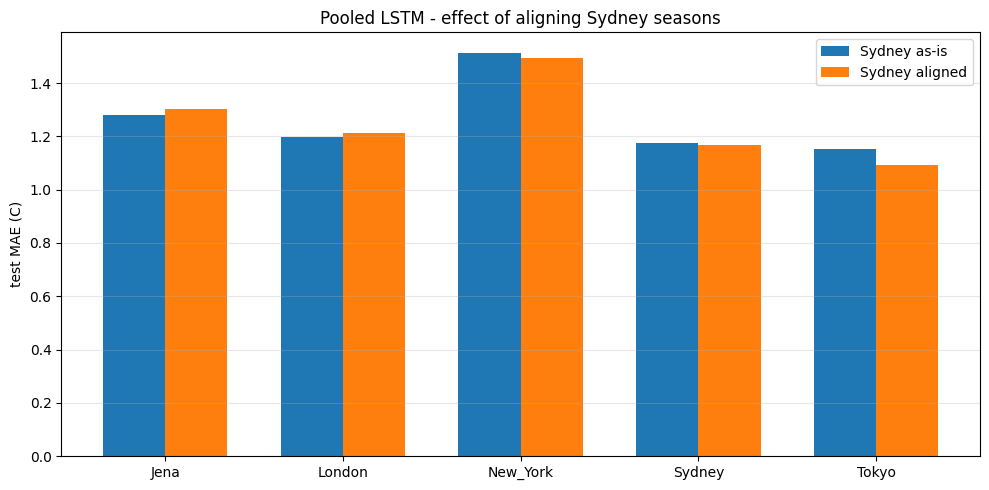

In [9]:
x = np.arange(len(CITIES)); w = 0.35
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(x-w/2, [base_city[c] for c in CITIES], w, label='Sydney as-is')
ax.bar(x+w/2, [alg_city[c] for c in CITIES], w, label='Sydney aligned')
ax.set_xticks(x); ax.set_xticklabels(CITIES)
ax.set_ylabel('test MAE (C)')
ax.set_title('Pooled LSTM - effect of aligning Sydney seasons')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS, 'sydney_alignment.png'), dpi=150)
plt.show()

## reading the result

Overall MAE went from 1.264 (Sydney as-is) to 1.254 (Sydney aligned), a change of about 0.01 C. Sydney's own MAE barely moved either, 1.176 to 1.168. The per-city changes are all tiny and mixed (Tokyo improved a little, Jena and London got very slightly worse), all well within normal run-to-run noise.

So the honest conclusion is that aligning Sydney's seasons makes almost no difference to the pooled LSTM. That is actually the interesting finding: the model was not being confused by the reversed seasonality in the first place. It already has the one-hot city indicator and the lat/lon of each city as inputs, so it can learn Sydney's opposite seasonal pattern on its own without needing the manual six-month shift. The transform only helps if the model has no other way to tell the cities apart, which is not the case here.

Worth noting the baseline here (1.264) lines up with the pooled result from the RQ2 notebook (1.268), so the lighter local config is behaving consistently.

If the dataset were expanded to many more cities the story could change, and the seasonal alignment might matter more, but for these 5 cities with explicit city and location inputs it is not needed.